# 02 — Análisis Exploratorio de Datos (EDA)

**Colaborador responsable:** Paola Mildred Martínez Hidalgo

EDA completo del dataset COVID-19/Influenza, incluyendo estadísticas descriptivas, detección de outliers, correlaciones y reglas de asociación.

## 1. Setup y configuración

In [ ]:
import sys
from pathlib import Path

# Añadir la raíz del proyecto al path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Semilla de reproducibilidad
from src.utils.constants import RANDOM_STATE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import plotly.express as px  # Para visualizaciones interactivas

from src.utils.visualization import *
from src.utils.constants import (
    COLS_COMORBILIDADES, COLS_DEMOGRAFICAS,
    SEVERIDAD_MAP, DATA_CLEAN_PATH
)

## 2. Carga de datos limpios

In [ ]:
# TODO: Cargar el CSV limpio exportado por el notebook 01
# df = pd.read_csv(DATA_CLEAN_PATH / "COVID19MEXICO_clean.csv")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as scipy_stats

df = pd.read_csv(
    "COVID19MEXICO_clean.csv",
    parse_dates=["FECHA_INGRESO", "FECHA_SINTOMAS", "FECHA_DEF"],
    low_memory=False
)

print(f"Filas   : {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head(10)

Filas   : 222,379
Columnas: 44


,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI,SEVERIDAD,EDAD_SCALED
0,2026-06-01,gaa41ae,1,15,21,1,15,21,41,1,...,2,97,7,7,NaN,MÃ©xico,97,0.0,1,1.584416
1,2026-06-01,g6e9f48,1,4,22,0,22,22,14,1,...,2,97,7,7,NaN,MÃ©xico,97,0.0,1,1.054996
2,2026-06-01,g8c8897,1,15,30,0,30,30,131,0,...,2,97,7,7,NaN,MÃ©xico,97,NaN,0,-1.100500
3,2026-06-01,gbe1773,1,4,32,0,32,32,17,1,...,2,97,7,7,NaN,MÃ©xico,97,0.0,1,-1.251763
4,2026-06-01,gc47f8c,1,4,21,0,21,21,114,0,...,2,97,7,3,NaN,MÃ©xico,97,NaN,0,1.319706
5,2026-06-01,gb6bae3,1,4,21,0,21,21,114,0,...,2,97,6,6,NaN,MÃ©xico,97,NaN,0,0.109603
6,2026-06-01,gc9c7d6,1,15,2,0,2,2,2,1,...,2,97,7,3,NaN,MÃ©xico,97,0.0,1,0.676839
7,2026-06-01,gaff20b,1,4,22,0,22,22,14,1,...,2,97,7,7,NaN,MÃ©xico,97,0.0,1,-0.722343
8,2026-06-01,g89e208,1,12,19,1,19,19,18,1,...,2,97,7,7,NaN,MÃ©xico,97,0.0,1,-1.289578
9,2026-06-01,gd96c4e,1,4,30,0,30,30,44,0,...,2,97,6,6,NaN,MÃ©xico,97,NaN,0,0.223050


## 3. Estadísticas descriptivas

### 3.1 Variables numéricas

La única variable continua real que tenemos es `EDAD`. `EDAD_SCALED` es su versión estandarizada, pero en este caso usaremos `EDAD`para resultados más certeros.

Media            = 35.10 años
Mediana          = 32 años
Moda (aprox)     = 1 años


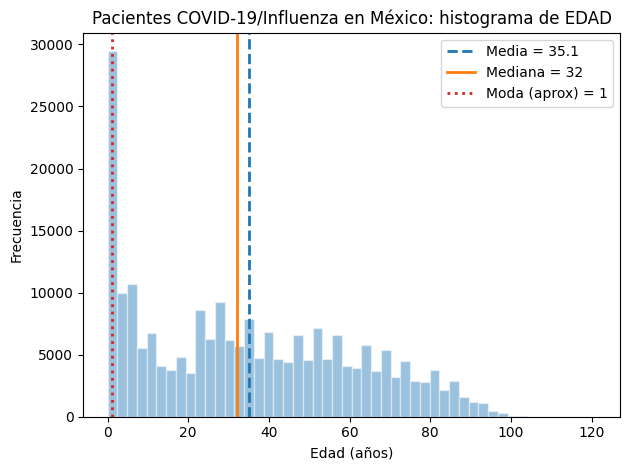

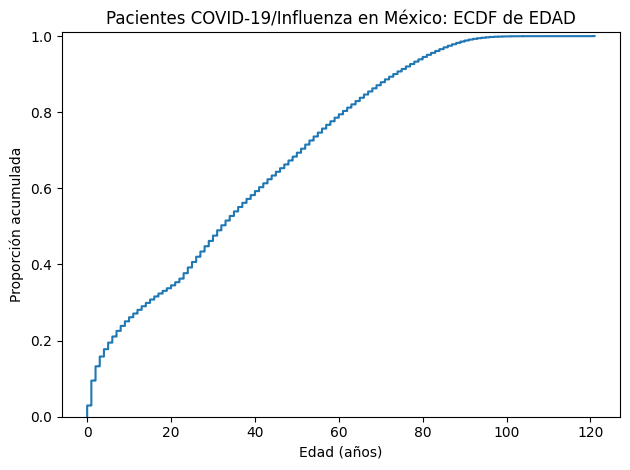

P25=9 años,  P50=32 años,  P75=56 años
P90=73 años,  P95=81 años


In [ ]:
#| label: tbl-estadisticas-numericas
#| tbl-cap: "Estadísticas descriptivas de variables numéricas"

# Usando dataset limpio
edad = df["EDAD"].dropna().values

# Medidas de localización
mean   = edad.mean()
median = np.median(edad)

# Moda aproximada: centro del bin con mayor frecuencia
bins = 50
counts, bin_edges = np.histogram(edad, bins=bins)
max_bin_idx = np.argmax(counts)
mode_approx = 0.5 * (bin_edges[max_bin_idx] + bin_edges[max_bin_idx + 1])

print(f"Media            = {mean:.2f} años")
print(f"Mediana          = {median:.0f} años")
print(f"Moda (aprox)     = {mode_approx:.0f} años")

# Histograma con líneas de localización
plt.figure()
plt.hist(edad, bins=bins, alpha=0.45, edgecolor="white")
plt.title("Pacientes COVID-19/Influenza en México: histograma de EDAD")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")

plt.axvline(mean,        color="tab:blue",   linestyle="--", linewidth=2, label=f"Media = {mean:.1f}")
plt.axvline(median,      color="tab:orange", linestyle="-",  linewidth=2, label=f"Mediana = {median:.0f}")
plt.axvline(mode_approx, color="tab:red",    linestyle=":",  linewidth=2, label=f"Moda (aprox) = {mode_approx:.0f}")

plt.legend()
plt.tight_layout()
plt.show()

# Función de Distribución Acumulada Empírica (ECDF)
x_sorted = np.sort(edad)
y = np.arange(1, x_sorted.size + 1) / x_sorted.size

plt.figure()
plt.step(x_sorted, y, where="post")
plt.title("Pacientes COVID-19/Influenza en México: ECDF de EDAD")
plt.xlabel("Edad (años)")
plt.ylabel("Proporción acumulada")
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()

# Percentiles
p25, p50, p75, p90, p95 = np.quantile(edad, [0.25, 0.50, 0.75, 0.90, 0.95])
print(f"P25={p25:.0f} años,  P50={p50:.0f} años,  P75={p75:.0f} años")
print(f"P90={p90:.0f} años,  P95={p95:.0f} años")

La edad de los pacientes presenta una media de 35 años y una mediana de 32 años, lo que indica que la mitad de los pacientes tiene 32 años o menos y la otra mitad 32 años o más. Dado que la media es ligeramente superior a la mediana, la distribución de edades parece presentar una asimetría positiva, es decir, existe una proporción de pacientes de edades avanzadas que incrementa el promedio.

La moda aproximada de 1 año refleja que los lactantes (menores de 2 años) son el grupo etario con mayor número de registros individuales en el dataset. Sin embargo, como medida de tendencia central no es representativa del paciente típico. La mediana de 32 años es el estadístico más adecuado para describir la edad central de la población estudiada, ya que no se ve afectada por esta concentración en edades tempranas.

Los percentiles permiten comprender mejor cómo se distribuyen las edades:

- P25 = 9 años: el 25% de los pacientes tiene 9 años o menos.
- P50 = 32 años: corresponde a la mediana; el 50% de los pacientes tiene 32 años o menos.
- P75 = 56 años: el 75% de los pacientes tiene 56 años o menos, mientras que el 25% restante supera esta edad.
- P90 = 73 años: el 90% de los pacientes tiene 73 años o menos; únicamente el 10% tiene más de 73 años.
- P95 = 81 años: el 95% de los pacientes tiene 81 años o menos, por lo que solo el 5% supera esta edad.

Los resultados muestran una distribución amplia de edades, que abarca desde niños pequeños hasta adultos mayores. El 50% central de los pacientes se encuentra entre 9 y 56 años, mientras que las edades más avanzadas son menos frecuentes pero suficientes para elevar la media por encima de la mediana. Esto sugiere que la población afectada incluye una proporción importante de pacientes jóvenes y adultos, aunque también existen casos en adultos mayores que representan los valores más extremos de la distribución.


Varianza:            699.2900 años²
Desviación estándar: 26.4441 años
Media:               35.10 años


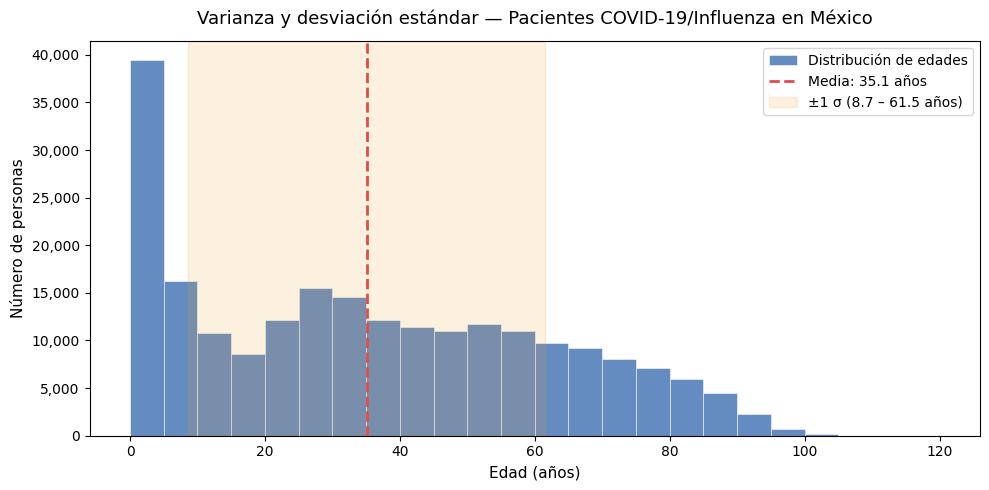

In [ ]:
#| label: tbl-desviacion-estandar
#| tbl-cap: "Estadísticas descriptivas de variables numéricas para desviación estandar"

df['EDAD'] = pd.to_numeric(df['EDAD'], errors='coerce')
edad = df['EDAD'].dropna()

# Medidas de variabilidad
varianza = edad.var(ddof=1)
desv_std = edad.std(ddof=1)
media    = edad.mean()

print(f"Varianza:            {varianza:.4f} años²")
print(f"Desviación estándar: {desv_std:.4f} años")
print(f"Media:               {media:.2f} años")

# Gráfica
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(edad, bins=range(0, 121, 5), color='#3266ad', alpha=0.75,
        edgecolor='white', linewidth=0.5, label='Distribución de edades')

# Línea de la media
ax.axvline(media, color='#E24B4A', linewidth=2, linestyle='--',
           label=f'Media: {media:.1f} años')

# Banda de ±1 desviación estándar
ax.axvspan(media - desv_std, media + desv_std,
           alpha=0.15, color='#EF9F27',
           label=f'±1 σ ({media - desv_std:.1f} – {media + desv_std:.1f} años)')

ax.set_title('Varianza y desviación estándar — Pacientes COVID-19/Influenza en México', fontsize=13, pad=12)
ax.set_xlabel('Edad (años)', fontsize=11)
ax.set_ylabel('Número de personas', fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

Para interpretar la varianza nos apoyamos en la desviación estándar. En este caso, la desviación estándar es de 26.44 años, lo que indica que las edades de los pacientes con COVID-19 e influenza se dispersan, en promedio, aproximadamente 26 años por encima o por debajo de la media de 35.10 años. Esto implica que el rango típico de edades se encuentra entre 9 años (35.10 − 26.44) y 62 años (35.10 + 26.44), abarcando desde niños y adolescentes hasta adultos de mediana edad.

Esta amplitud refleja que ambas enfermedades afectan a personas de distintos grupos etarios y no se concentran exclusivamente en una edad específica. Sin embargo, al considerar conjuntamente la mediana de 32 años, el percentil 25 de 9 años y la moda de 1 año, se observa una importante presencia de pacientes jóvenes dentro del conjunto de datos. Esto sugiere que una proporción considerable de los casos registrados corresponde a niños, adolescentes y adultos jóvenes.

Asimismo, la diferencia entre la media (35.10 años) y los percentiles superiores (P90 = 73 años y P95 = 81 años) evidencia la existencia de pacientes de edad avanzada que incrementan la dispersión de los datos. En conjunto, estos resultados muestran una distribución de edades heterogénea, con presencia de casos en prácticamente todas las etapas de la vida, desde la infancia hasta la vejez.

### 3.2 Variables categóricas

Frecuencias y moda.

In [ ]:
# TODO: Frecuencias de cada variable categórica
#| label: tbl-frecuencias-categoricas
#| tbl-cap: "Frecuencias y moda de variables categóricas clave"

COLS_COMORBILIDADES = [
    "DIABETES", "EPOC", "ASMA", "INMUSUPR", "HIPERTENSION",
    "CARDIOVASCULAR", "OBESIDAD", "RENAL_CRONICA", "TABAQUISMO", "OTRA_COM"
]

cols_cat = COLS_COMORBILIDADES + [
    "SEXO", "TIPO_PACIENTE", "NEUMONIA", "UCI", "INTUBADO",
    "INDIGENA", "HABLA_LENGUA_INDIG", "MIGRANTE"
]

print(f"{'Variable':<22} {'N válidos':>10} {'N nulos':>8} {'% Moda':>8} {'% Presencia(=1)':>16}")
print("-" * 75)
for col in cols_cat:
    if col not in df.columns:
        continue
    s = df[col].dropna()
    vc = s.value_counts()
    moda = vc.idxmax()
    pct_moda = vc.max() / len(s) * 100
    pct_1    = (s == 1).mean() * 100
    nulos    = df[col].isna().sum()
    print(f"{col:<22} {len(s):>10,} {nulos:>8,} {pct_moda:>7.1f}% {pct_1:>15.1f}%")

Variable                N válidos  N nulos   % Moda  % Presencia(=1)
---------------------------------------------------------------------------
DIABETES                  222,100      279    86.9%            13.1%
EPOC                      222,093      286    96.6%             3.4%
ASMA                      222,088      291    95.9%             4.1%
INMUSUPR                  222,171      208    96.9%             3.1%
HIPERTENSION              222,170      209    84.1%            15.9%
CARDIOVASCULAR            222,156      223    96.7%             3.3%
OBESIDAD                  222,190      189    93.4%             6.6%
RENAL_CRONICA             222,181      198    96.5%             3.5%
TABAQUISMO                222,117      262    95.7%             4.3%
OTRA_COM                  220,589    1,790    94.6%             5.4%
SEXO                      222,379        0    55.1%            44.9%
TIPO_PACIENTE             222,379        0    52.3%            47.7%
NEUMONIA                  2

El análisis de frecuencia y moda de las variables categóricas permite identificar la distribución de las principales características clínicas y demográficas de la población estudiada.

Entre las comorbilidades registradas, la hipertensión arterial fue la más frecuente, presente en el 15.9% de los pacientes, seguida por la diabetes con 13.1%. Estas dos enfermedades destacan por su prevalencia y son ampliamente reconocidas como factores de riesgo asociados a complicaciones en enfermedades respiratorias, por lo que podrían desempeñar un papel importante en los modelos predictivos de severidad y mortalidad.

Otras comorbilidades mostraron una menor frecuencia de aparición. La obesidad estuvo presente en el 6.6% de los pacientes, mientras que otra comorbilidad representó el 5.4%. El tabaquismo (4.3%), el asma (4.1%), la enfermedad renal crónica (3.5%), la EPOC (3.4%), las enfermedades cardiovasculares (3.3%) y la inmunosupresión (3.1%) presentaron porcentajes relativamente bajos de manera individual. No obstante, la coexistencia de varias de estas condiciones en un mismo paciente podría incrementar significativamente el riesgo de desarrollar cuadros graves.

Respecto a las variables clínicas, el 25.0% de los pacientes presentó neumonía, una de las complicaciones respiratorias más relevantes dentro de la evolución de enfermedades como COVID-19 e influenza. Asimismo, el 3.0% de los pacientes requirió ingreso a Unidad de Cuidados Intensivos (UCI) y el 4.4% necesitó intubación, lo que sugiere que los casos críticos constituyen una proporción relativamente pequeña del total de la muestra.

En las variables sociodemográficas, el 1.8% de los pacientes se identificó como indígena y el 1.3% reportó hablar una lengua indígena. Estas proporciones indican una baja representación de estos grupos dentro de la base analizada.

Finalmente, se observa que la variable MIGRANTE presenta una cantidad extremadamente elevada de valores faltantes (221,559 registros, equivalentes a más del 99% de la muestra). Debido a esta ausencia masiva de información, su capacidad explicativa es limitada.

### 3.3 Distribución del target (SEVERIDAD)

Análisis de balance de clases.

Nivel Descripción                       Casos       %
-------------------------------------------------------
  0    Leve                            116,190   52.2%
  1    Grave                            93,828   42.2%
  2    Crítico                           4,114    1.8%
  3    Fallecido                         8,247    3.7%
-------------------------------------------------------
  Total                                222,379  100.0%


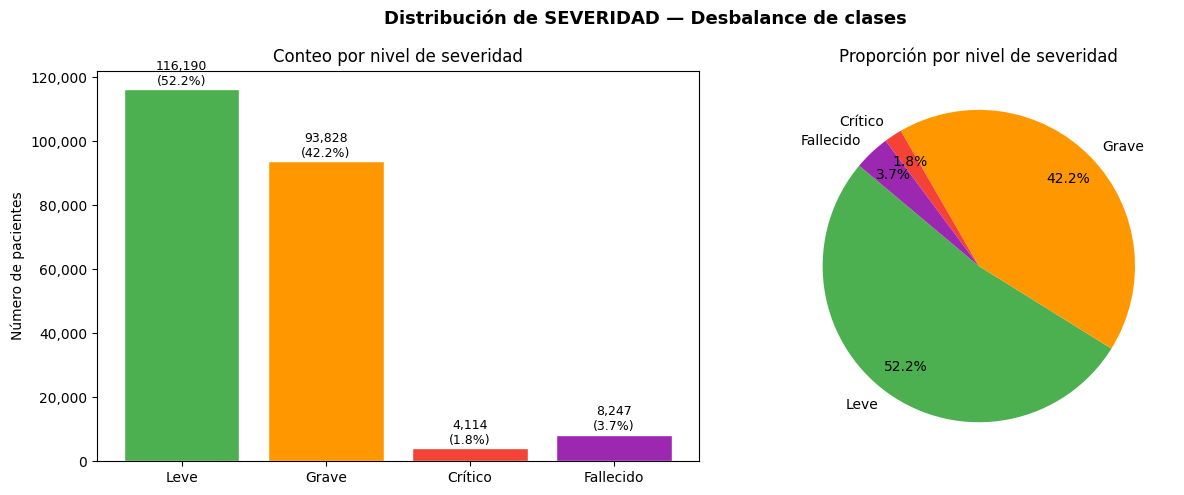

In [ ]:
#| label: fig-distribucion-target
#| fig-cap: "Distribución de la variable objetivo SEVERIDAD"

SEVERIDAD_MAP = {0: "Leve", 1: "Grave", 2: "Crítico", 3: "Fallecido"}
SEVERIDAD_COLORS = ["#4CAF50", "#FF9800", "#2E1AB1", "#9C27B0"]

dist_sev = df["SEVERIDAD"].value_counts().sort_index()
total    = dist_sev.sum()
labels   = [SEVERIDAD_MAP.get(i, str(i)) for i in dist_sev.index]

# Tabla
print(f"{'Nivel':<5} {'Descripción':<30} {'Casos':>8} {'%':>7}")
print("-" * 55)
for nivel, desc in SEVERIDAD_MAP.items():
    n = dist_sev.get(nivel, 0)
    print(f"  {nivel}    {desc:<30} {n:>8,} {n/total*100:>6.1f}%")
print("-" * 55)
print(f"  Total{'':<30} {total:>8,}  100.0%")

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(labels, dist_sev.values, color=SEVERIDAD_COLORS, edgecolor="white")
for bar, n in zip(bars, dist_sev.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.002,
        f"{n:,}\n({n/total*100:.1f}%)", ha="center", va="bottom", fontsize=9
    )
axes[0].set_title("Conteo por nivel de severidad")
axes[0].set_ylabel("Número de pacientes")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].pie(
    dist_sev.values, labels=labels, colors=SEVERIDAD_COLORS,
    autopct="%1.1f%%", startangle=140, pctdistance=0.8
)
axes[1].set_title("Proporción por nivel de severidad")

plt.suptitle("Distribución de SEVERIDAD — Desbalance de clases", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

En las gráficas anteriores se presenta la distribución de los pacientes según el nivel de severidad clínica definido para el estudio. Para cada registro se asignó una categoría de severidad (Leve, Grave, Crítico o Fallecido) con base en las características clínicas y el desenlace reportado en la base de datos. Posteriormente, se contabilizó el número de pacientes en cada categoría y se calculó el porcentaje correspondiente respecto al total de 222,379 pacientes analizados.

Los resultados muestran que la categoría más frecuente fue Leve, con 116,190 pacientes (52.2%), seguida de la categoría Grave, con 93,828 pacientes (42.2%). Los casos Críticos representaron 4,114 pacientes (1.8%), mientras que 8,247 pacientes (3.7%) fueron clasificados como Fallecidos.

Esta distribución indica que poco más de la mitad de los pacientes presentó cuadros leves; sin embargo, una proporción considerable evolucionó hacia condiciones graves, críticas o fallecimiento. Estos resultados justifican la aplicación de técnicas de minería de datos para identificar los factores asociados a los desenlaces más severos y desarrollar modelos predictivos que permitan una detección temprana de pacientes de alto riesgo.

## 4. Histogramas de variables numéricas

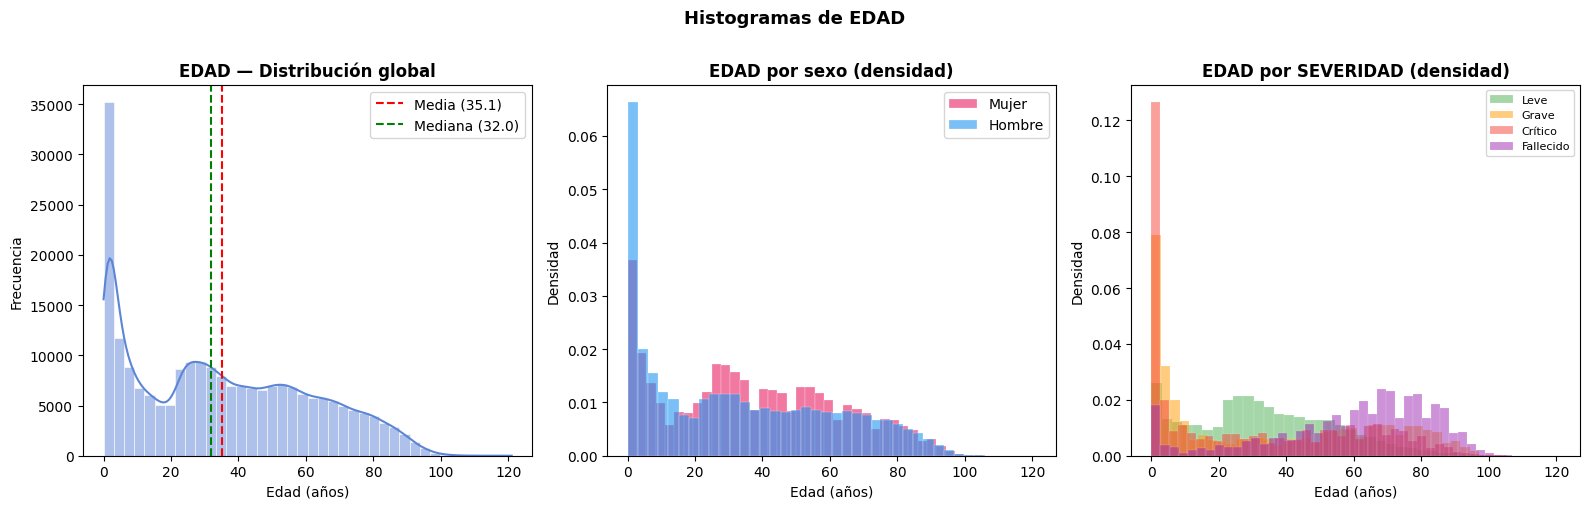

Estadísticos de EDAD por nivel de SEVERIDAD:
           mean  median   std  min  max
SEVERIDAD                              
0          33.7    32.0  20.7    0  121
1          35.0    29.0  31.3    0  111
2          29.1    20.0  29.0    0  105
3          59.7    65.0  24.4    0  107


In [ ]:
#| label: fig-histograma-edad
#| fig-cap: "Distribución de la variable EDAD"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma global de edad
sns.histplot(df["EDAD"].dropna(), bins=40, kde=True, ax=axes[0],
             color="#5C85D6", edgecolor="white", linewidth=0.4)
axes[0].axvline(df["EDAD"].mean(), color="red", linestyle="--", label=f"Media ({df['EDAD'].mean():.1f})")
axes[0].axvline(df["EDAD"].median(), color="green", linestyle="--", label=f"Mediana ({df['EDAD'].median():.1f})")
axes[0].set_title("EDAD — Distribución global", fontweight="bold")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Por sexo
sexo_labels = {0: "Mujer", 1: "Hombre"}
for sexo, color in zip([0, 1], ["#E91E63", "#2196F3"]):
    subset = df[df["SEXO"] == sexo]["EDAD"].dropna()
    axes[1].hist(subset, bins=40, alpha=0.6, color=color,
                 edgecolor="white", linewidth=0.3, label=sexo_labels[sexo], density=True)
axes[1].set_title("EDAD por sexo (densidad)", fontweight="bold")
axes[1].set_xlabel("Edad (años)")
axes[1].set_ylabel("Densidad")
axes[1].legend()

# --- Por SEVERIDAD ---
for nivel, color in zip(sorted(df["SEVERIDAD"].dropna().unique()), SEVERIDAD_COLORS):
    subset = df[df["SEVERIDAD"] == nivel]["EDAD"].dropna()
    axes[2].hist(subset, bins=40, alpha=0.5, color=color, density=True,
                 edgecolor="white", linewidth=0.2, label=SEVERIDAD_MAP.get(nivel, nivel))
axes[2].set_title("EDAD por SEVERIDAD (densidad)", fontweight="bold")
axes[2].set_xlabel("Edad (años)")
axes[2].set_ylabel("Densidad")
axes[2].legend(fontsize=8)

plt.suptitle("Histogramas de EDAD", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

plt.show()

# Estadísticos por severidad
print("Estadísticas de EDAD por nivel de SEVERIDAD:")
print(df.groupby("SEVERIDAD")["EDAD"].agg(["mean", "median", "std", "min", "max"]).round(1).to_string())

## 5. Detección de valores atípicos

Se aplican dos métodos: **regla IQR** y **z-score**.

=== Regla IQR EDAD===
  Q1=9.0  Q3=56.0  IQR=47.0
  Límite inferior: -61.5
  Límite superior: 126.5
  Outliers detectados: 0 (0.00%)
  Mediana=32.0
=== Z-score (|z| > 3) ===
  Outliers detectados: 0 (0.00%)
  Rango de outliers por z-score: nan – nan años

=== EDAD POR NIVEL DE SEVERIDAD (IQR) ===

Severidad 0 (Leve)
  Q1=19.0
  Mediana=32.0
  Q3=48.0
  IQR=29.0
  Límite inferior: -24.5
  Límite superior: 91.5

Severidad 1 (Grave)
  Q1=3.0
  Mediana=29.0
  Q3=65.0
  IQR=62.0
  Límite inferior: -90.0
  Límite superior: 158.0

Severidad 2 (Crítico)
  Q1=1.0
  Mediana=20.0
  Q3=56.0
  IQR=55.0
  Límite inferior: -81.5
  Límite superior: 138.5

Severidad 3 (Fallecido)
  Q1=47.0
  Mediana=65.0
  Q3=78.0
  IQR=31.0
  Límite inferior: 0.5
  Límite superior: 124.5


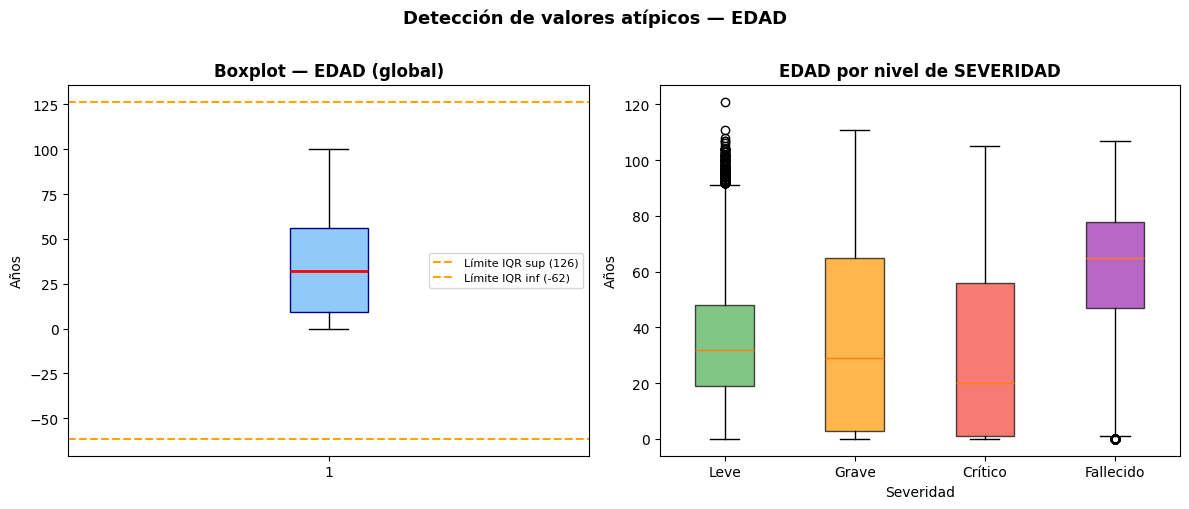

In [ ]:
#| label: fig-boxplots-outliers
#| fig-cap: "Boxplots para detección de outliers"

edad = df["EDAD"].dropna()
edad = edad[(edad >= 0) & (edad <= 100)]

# Regla IQR
Q1 = edad.quantile(0.25)
Q3 = edad.quantile(0.75)
IQR = Q3 - Q1
lim_inf_iqr = Q1 - 1.5 * IQR
lim_sup_iqr = Q3 + 1.5 * IQR
outliers_iqr = edad[(edad < lim_inf_iqr) | (edad > lim_sup_iqr)]

# Z-score
z_scores = np.abs(scipy_stats.zscore(edad))
outliers_z = edad[z_scores > 3]

print("=== Regla IQR EDAD===")
print(f"  Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}")

print(f"  Límite inferior: {lim_inf_iqr:.1f}")
print(f"  Límite superior: {lim_sup_iqr:.1f}")
print(f"  Outliers detectados: {len(outliers_iqr):,} ({len(outliers_iqr)/len(edad)*100:.2f}%)")
print(f"  Mediana={edad.median():.1f}")
print("=== Z-score (|z| > 3) ===")
print(f"  Outliers detectados: {len(outliers_z):,} ({len(outliers_z)/len(edad)*100:.2f}%)")
print(f"  Rango de outliers por z-score: {outliers_z.min():.0f} – {outliers_z.max():.0f} años")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot global
axes[0].boxplot(edad, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#90CAF9", color="navy"),
                medianprops=dict(color="red", linewidth=2))
axes[0].set_title("Boxplot — EDAD (global)", fontweight="bold")
axes[0].set_ylabel("Años")
axes[0].axhline(lim_sup_iqr, color="orange", linestyle="--", label=f"Límite IQR sup ({lim_sup_iqr:.0f})")
axes[0].axhline(lim_inf_iqr, color="orange", linestyle="--", label=f"Límite IQR inf ({lim_inf_iqr:.0f})")
axes[0].legend(fontsize=8)

# Boxplot por SEVERIDAD
df_plot = df[["EDAD", "SEVERIDAD"]].dropna()
print("\n=== EDAD POR NIVEL DE SEVERIDAD (IQR) ===")

for sev in sorted(df_plot["SEVERIDAD"].unique()):

    edades_sev = df_plot[df_plot["SEVERIDAD"] == sev]["EDAD"]

    Q1 = edades_sev.quantile(0.25)
    Q3 = edades_sev.quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    print(f"\nSeveridad {sev} ({SEVERIDAD_MAP.get(sev, sev)})")
    print(f"  Q1={Q1:.1f}")
    print(f"  Mediana={edades_sev.median():.1f}")
    print(f"  Q3={Q3:.1f}")
    print(f"  IQR={IQR:.1f}")
    print(f"  Límite inferior: {lim_inf:.1f}")
    print(f"  Límite superior: {lim_sup:.1f}")
groups = [df_plot[df_plot["SEVERIDAD"] == i]["EDAD"].values for i in sorted(df_plot["SEVERIDAD"].unique())]
bp = axes[1].boxplot(groups, patch_artist=True, tick_labels=[SEVERIDAD_MAP.get(i, i) for i in sorted(df_plot["SEVERIDAD"].unique())])
for patch, color in zip(bp["boxes"], SEVERIDAD_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("EDAD por nivel de SEVERIDAD", fontweight="bold")
axes[1].set_ylabel("Años")
axes[1].set_xlabel("Severidad")

plt.suptitle("Detección de valores atípicos — EDAD", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

El análisis de la variable edad mediante la regla del rango intercuartílico (IQR) y el método Z-score no identificó valores atípicos significativos dentro del conjunto de datos. Para la población total, la mediana fue de 32 años y el 50% central de las edades se ubicó entre 9 y 56 años, lo que evidencia una amplia diversidad etaria entre los pacientes incluidos en el estudio.

Al segmentar la edad por nivel de severidad, se observan diferencias importantes en la distribución de los grupos. Los pacientes clasificados como leves presentaron una mediana de 32 años y un rango intercuartílico entre 19 y 48 años, mostrando una mayor concentración en adultos jóvenes y de mediana edad.

Los grupos grave y crítico mostraron una dispersión considerablemente mayor. En los casos graves, el 50% central de las edades se encontró entre 3 y 65 años, mientras que en los casos críticos se ubicó entre 1 y 56 años. La presencia simultánea de pacientes pediátricos y adultos mayores dentro de estas categorías genera una elevada variabilidad y explica las medianas relativamente bajas observadas en ambos grupos.

Por otra parte, el grupo de pacientes fallecidos presentó una distribución claramente desplazada hacia edades avanzadas. La mediana fue de 65 años y el rango intercuartílico se ubicó entre 47 y 78 años, lo que indica que al menos la mitad de las defunciones ocurrió en adultos mayores. Asimismo, la media de edad de este grupo fue de 59 años, considerablemente superior a la observada en los demás niveles de severidad.

En conjunto, los resultados sugieren que la mortalidad se concentra principalmente en pacientes de edad avanzada, mientras que los casos graves y críticos afectan a una población más heterogénea que incluye tanto pacientes pediátricos como adultos mayores. Este comportamiento puede estar relacionado con las enfermedades respiratorias incluidas en el estudio, las cuales presentan patrones de riesgo diferenciados según la edad.

## 6. Matriz de correlación

Se usa **Spearman** porque la mayoría de variables son binarias o de escala ordinal, por lo que Pearson no es apropiado.

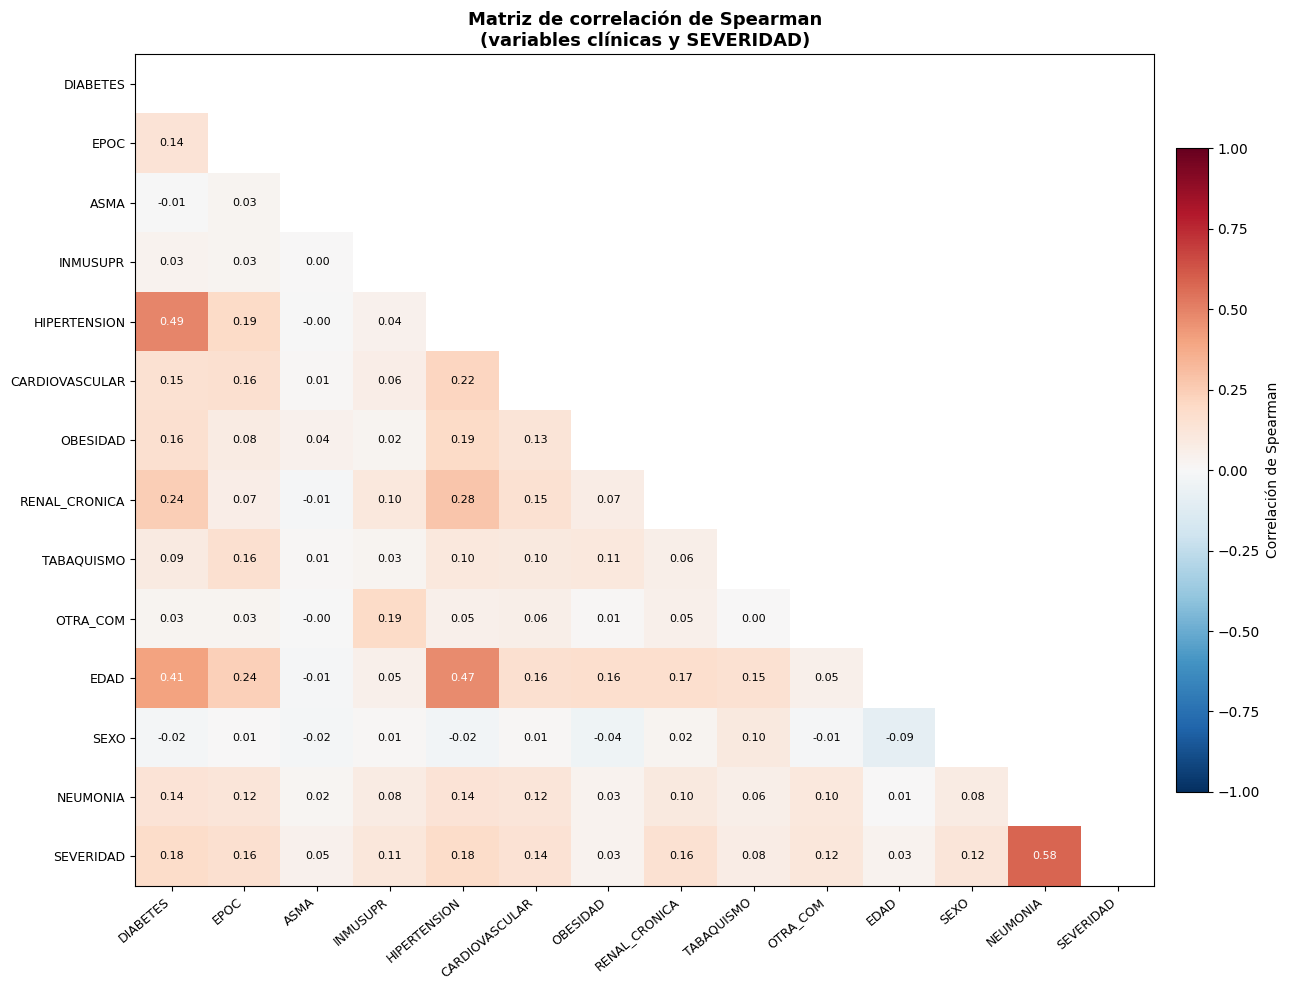

In [ ]:
COLS_COMORBILIDADES = [
    "DIABETES", "EPOC", "ASMA", "INMUSUPR", "HIPERTENSION",
    "CARDIOVASCULAR", "OBESIDAD", "RENAL_CRONICA", "TABAQUISMO", "OTRA_COM"
]

cols_corr = COLS_COMORBILIDADES + ["EDAD", "SEXO", "NEUMONIA", "SEVERIDAD"]
cols_corr = [c for c in cols_corr if c in df.columns]

corr = df[cols_corr].corr(method="spearman", numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))

im = ax.imshow(np.where(mask, np.nan, corr.values),
               cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Correlación de Spearman")

ax.set_xticks(range(len(cols_corr)))
ax.set_yticks(range(len(cols_corr)))
ax.set_xticklabels(cols_corr, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(cols_corr, fontsize=9)

for i in range(len(corr)):
    for j in range(len(corr)):
        if not mask[i, j]:
            val = corr.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(val) > 0.4 else "black")

ax.set_title("Matriz de correlación de Spearman\n(variables clínicas y SEVERIDAD)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretación general de la matriz de correlación

La matriz de correlación de Spearman permite evaluar la relación entre las variables clínicas, demográficas y el nivel de severidad de los pacientes. En términos generales, las correlaciones observadas son bajas a moderadas, lo que indica que ninguna variable por sí sola explica completamente la evolución clínica de los pacientes. Este resultado nos hace ver que la severidad de las enfremedades suele depender de la interacción de múltiples factores de riesgo.

La variable que presenta la asociación más fuerte con la severidad es la neumonía (ρ = 0.58), indicando una relación positiva moderadamente alta. Esto significa que los pacientes que desarrollan neumonía tienden a presentar niveles de severidad más elevados, lo cual es coherente con la evolución clínica observada en enfermedades respiratorias como COVID-19 e influenza.

Entre las comorbilidades, las correlaciones más altas corresponden a diabetes (ρ = 0.18), hipertensión (ρ = 0.18), EPOC (ρ = 0.16) y enfermedad renal crónica (ρ = 0.16). Aunque estas asociaciones son relativamente bajas, sugieren que dichas condiciones contribuyen al incremento del riesgo de complicaciones.

### Relaciones entre comorbilidades

Podemos ver unas asociaciones entre enfermedades:

- Diabetes e hipertensión (ρ = 0.49)

  La correlación más alta entre las comorbilidades se observa entre diabetes e hipertensión (ρ = 0.49). Esta relación moderada indica que ambas enfermedades tienden a coexistir con frecuencia en los mismos pacientes.

- Edad e hipertensión (ρ = 0.47)

  La edad presenta una correlación moderada con la hipertensión (ρ = 0.47), sugiriendo que la prevalencia de esta enfermedad aumenta conforme incrementa la edad de los pacientes.

- Edad y diabetes (ρ = 0.41)

  También se observa una asociación positiva entre edad y diabetes (ρ = 0.41), lo que indica una mayor presencia de esta comorbilidad en adultos y adultos mayores.

- Edad y EPOC (ρ = 0.24)

  La correlación entre edad y EPOC (ρ = 0.24) muestra que esta enfermedad respiratoria crónica es más frecuente en grupos de mayor edad.

## 7. Análisis de variables categóricas

Gráficas de barras con frecuencias por variable de prevalencia de comorbilidades.

Prevalencia de comorbilidades (%):
  INMUSUPR               3.1%
  CARDIOVASCULAR         3.3%
  EPOC                   3.4%
  RENAL_CRONICA          3.5%
  ASMA                   4.1%
  TABAQUISMO             4.3%
  OTRA_COM               5.4%
  OBESIDAD               6.6%
  DIABETES               13.1%
  HIPERTENSION           15.9%


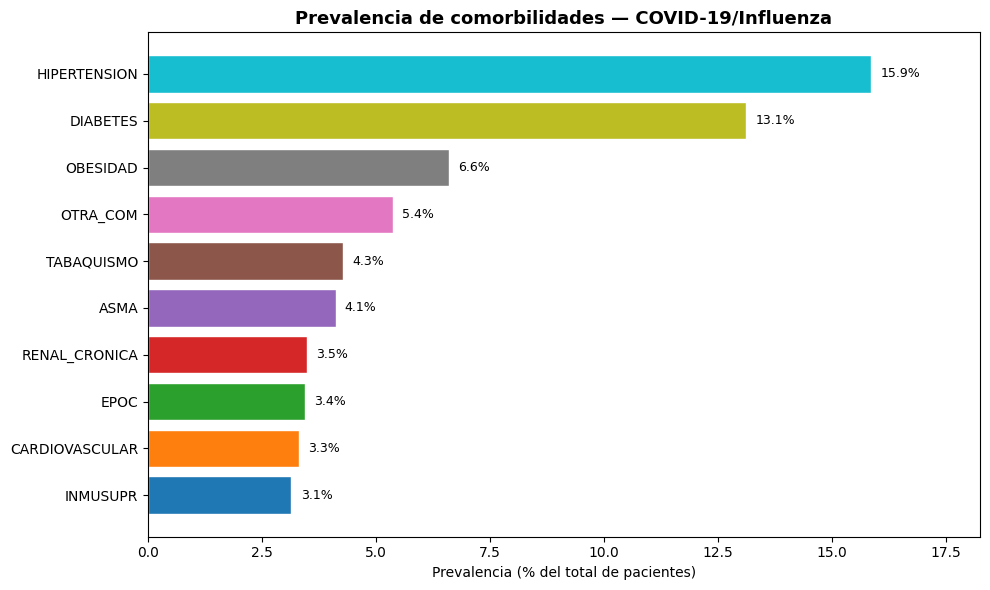

In [62]:
#| label: fig-barras-comorbilidades
#| fig-cap: "Frecuencia de comorbilidades en la población"

COLS_COMORBILIDADES = [
    "DIABETES", "EPOC", "ASMA", "INMUSUPR", "HIPERTENSION",
    "CARDIOVASCULAR", "OBESIDAD", "RENAL_CRONICA", "TABAQUISMO", "OTRA_COM"
]

prevalencia = df[COLS_COMORBILIDADES].mean().sort_values(ascending=True) * 100

print("Prevalencia de comorbilidades (%):")
for col, val in prevalencia.items():
    print(f"  {col:<22} {val:.1f}%")

colors = plt.cm.tab10(np.linspace(0, 1, len(prevalencia)))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prevalencia.index, prevalencia.values, color=colors, edgecolor="white")
for bar, val in zip(bars, prevalencia.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Prevalencia (% del total de pacientes)")
ax.set_title("Prevalencia de comorbilidades — COVID-19/Influenza", fontsize=13, fontweight="bold")
ax.set_xlim(0, prevalencia.max() * 1.15)
plt.tight_layout()
plt.show()

La prevalencia de comorbilidades muestra que las enfermedades crónicas más frecuentes en la población estudiada fueron la hipertensión arterial (15.9%) y la diabetes mellitus (13.1%), afectando aproximadamente a uno de cada seis y uno de cada ocho pacientes, respectivamente. Estas condiciones destacan como los principales antecedentes clínicos de la muestra y constituyen factores de riesgo ampliamente reconocidos para el desarrollo de complicaciones en enfermedades respiratorias.

En un segundo nivel de frecuencia se encuentran la obesidad (6.6%) y la categoría de otras comorbilidades (5.4%), seguidas por el tabaquismo (4.3%) y el asma (4.1%). Aunque su prevalencia es menor, estas condiciones pueden contribuir al deterioro de la función respiratoria y aumentar la vulnerabilidad de los pacientes ante infecciones respiratorias agudas.

Las comorbilidades con menor presencia fueron la enfermedad renal crónica (3.5%), la EPOC (3.4%), las enfermedades cardiovasculares (3.3%) y la inmunosupresión (3.1%). A pesar de su baja frecuencia relativa, estas patologías suelen estar asociadas con mayores tasas de complicaciones, hospitalización y mortalidad, por lo que su impacto clínico puede ser significativo incluso cuando afectan a una proporción reducida de pacientes.

Los resultados muestran una importante presencia de enfermedades crónicas no transmisibles dentro de la población analizada, particularmente hipertensión y diabetes. Este hallazgo coincide con el perfil epidemiológico de México, donde estas patologías representan algunos de los principales problemas de salud pública.

## 8. Visualizaciones avanzadas

### 8.1 Distribución geográfica (por entidad)

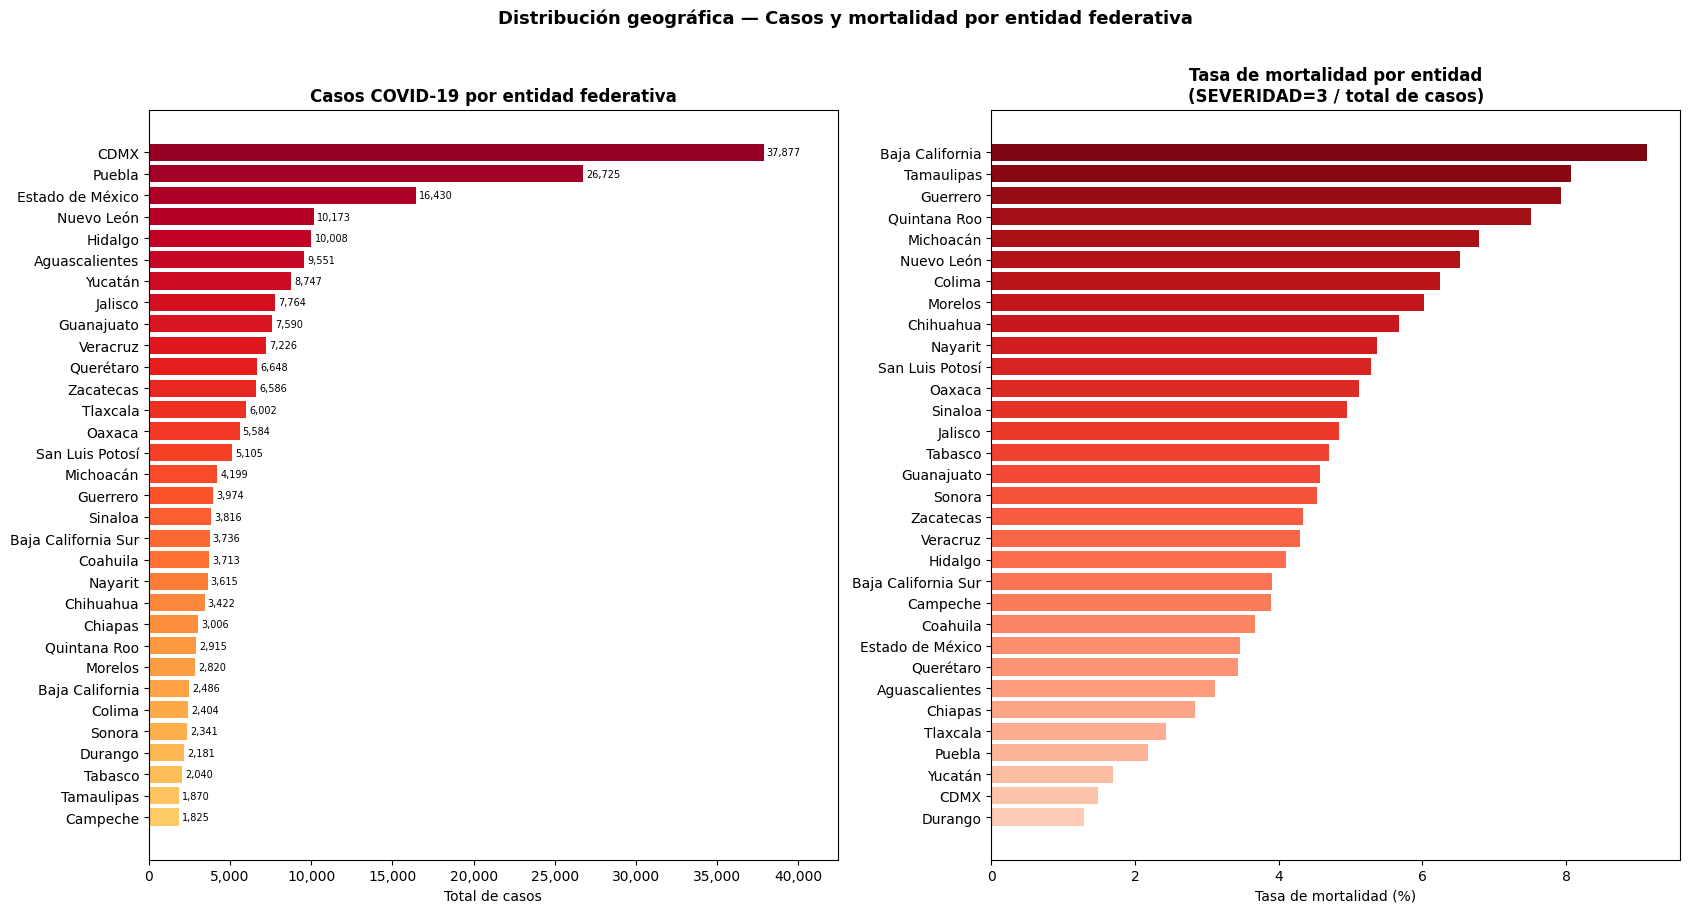

In [66]:
#| label: fig-mapa-entidades
#| fig-cap: "Distribución de casos por entidad federativa (ENTIDAD_RES)"

# Catálogo INEGI (01-32)
ENTIDAD_NOMBRES = {
    1: "Aguascalientes", 2: "Baja California", 3: "Baja California Sur",
    4: "Campeche", 5: "Coahuila", 6: "Colima", 7: "Chiapas",
    8: "Chihuahua", 9: "CDMX", 10: "Durango", 11: "Guanajuato",
    12: "Guerrero", 13: "Hidalgo", 14: "Jalisco", 15: "Estado de México",
    16: "Michoacán", 17: "Morelos", 18: "Nayarit", 19: "Nuevo León",
    20: "Oaxaca", 21: "Puebla", 22: "Querétaro", 23: "Quintana Roo",
    24: "San Luis Potosí", 25: "Sinaloa", 26: "Sonora", 27: "Tabasco",
    28: "Tamaulipas", 29: "Tlaxcala", 30: "Veracruz", 31: "Yucatán",
    32: "Zacatecas"
}

casos_estado = (
    df["ENTIDAD_RES"]
    .value_counts()
    .rename(index=ENTIDAD_NOMBRES)
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(17, 9))

# Barras horizontales — total de casos
colors_geo = plt.cm.YlOrRd(np.linspace(0.3, 0.95, len(casos_estado)))
bars = axes[0].barh(casos_estado.index, casos_estado.values, color=colors_geo)
for bar, n in zip(bars, casos_estado.values):
    axes[0].text(n + casos_estado.max() * 0.005,
                 bar.get_y() + bar.get_height() / 2,
                 f"{n:,}", va="center", fontsize=7)
axes[0].set_xlabel("Total de casos")
axes[0].set_title("Casos COVID-19 por entidad federativa", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_xlim(0, casos_estado.max() * 1.12)

# Tasa de mortalidad por entidad (SEVERIDAD == 3)
tasa_mort = (
    df.groupby("ENTIDAD_RES")["SEVERIDAD"]
    .apply(lambda x: (x == 3).sum() / len(x) * 100)
    .rename(index=ENTIDAD_NOMBRES)
    .sort_values(ascending=True)
)

colors_mort = plt.cm.Reds(np.linspace(0.2, 0.95, len(tasa_mort)))
axes[1].barh(tasa_mort.index, tasa_mort.values, color=colors_mort)
axes[1].set_xlabel("Tasa de mortalidad (%)")
axes[1].set_title("Tasa de mortalidad por entidad\n(SEVERIDAD=3 / total de casos)", fontweight="bold")

plt.suptitle("Distribución geográfica — Casos y mortalidad por entidad federativa",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Podemos observar que las entidades federativas con mayores casos de Covid-19 fue la CDMX con 37,877 casos, Puebla con 26,725 casos y el Estado de México con 16,430 casos. Mientras que las entidades con menor número de casos fue Tabasco con 2,040 casos, Tamaulipas con 1,870 casos y Campeche con 1,825 casos.

La tasa de mortalidad en cambio puede revelar desigualdades en acceso a servicios de salud: entidades con alta tasa relativa de fallecidos pese a pocos casos absolutamente pueden indicar sistemas de salud con menor capacidad de respuesta.

### 8.2 Series de tiempo

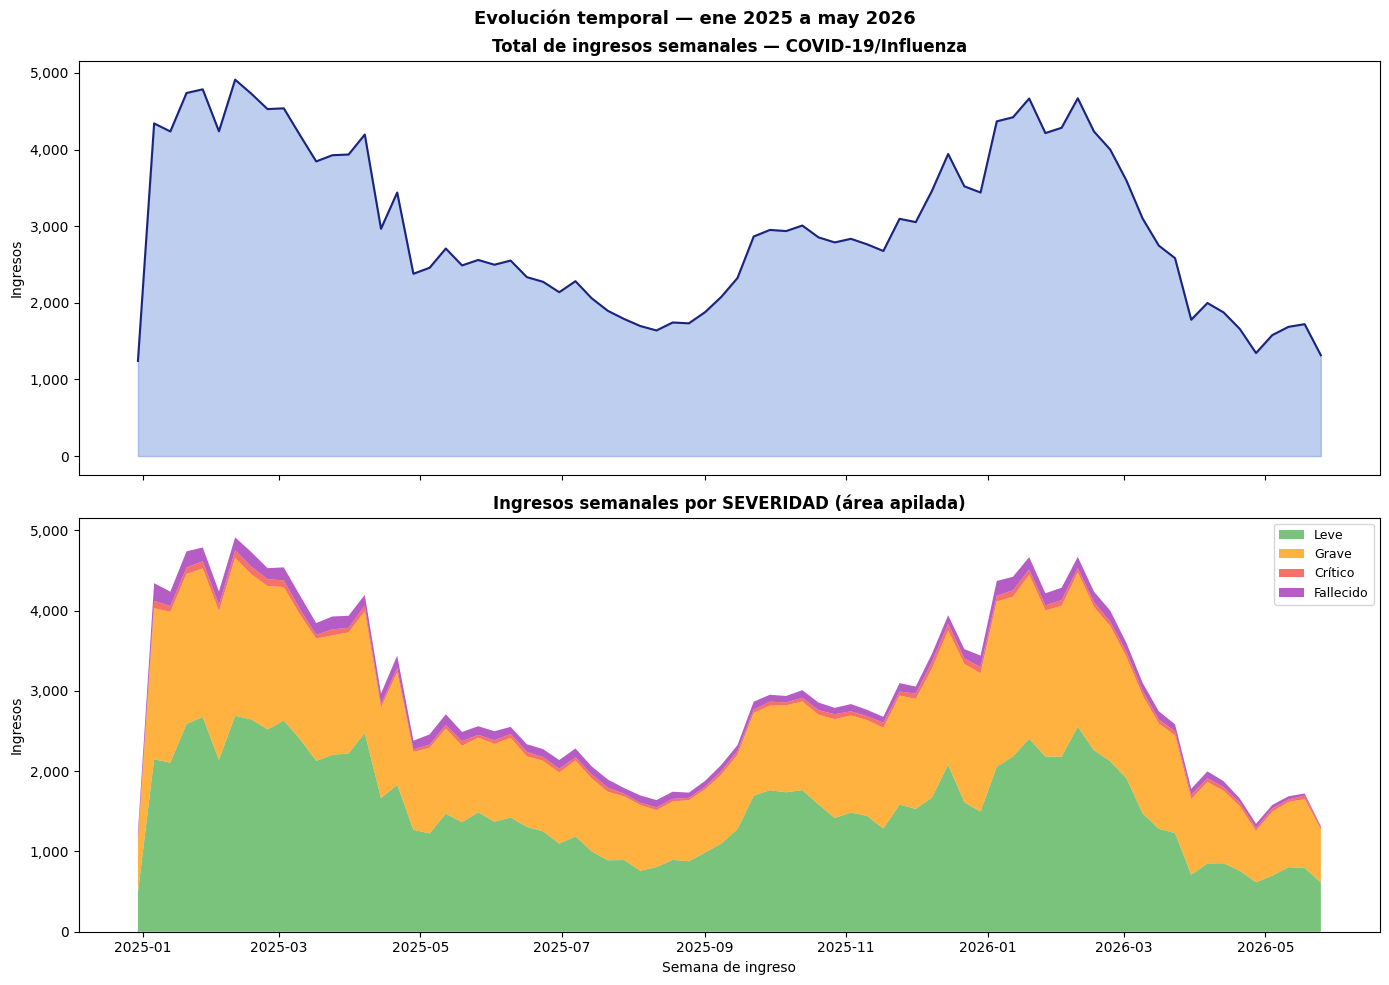

In [ ]:
#| label: fig-serie-tiempo
#| fig-cap: "Evolución temporal de ingresos y defunciones"

df = pd.read_csv(
    "COVID19MEXICO_clean.csv",
    parse_dates=["FECHA_INGRESO"],
    low_memory=False
)

SEVERIDAD_MAP    = {0: "Leve", 1: "Grave", 2: "Crítico", 3: "Fallecido"}
SEVERIDAD_COLORS = ["#4CAF50", "#FF9800", "#2E1AB1", "#9C27B0"]

df_t = df[["FECHA_INGRESO", "SEVERIDAD"]].dropna(subset=["FECHA_INGRESO"])
df_t = df_t.copy()
df_t["semana"] = df_t["FECHA_INGRESO"].dt.to_period("W").dt.start_time

casos_semana = df_t.groupby(["semana", "SEVERIDAD"]).size().unstack(fill_value=0)
total_semana = casos_semana.sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].fill_between(total_semana.index, total_semana.values, alpha=0.4, color="#5C85D6")
axes[0].plot(total_semana.index, total_semana.values, color="#1A237E", linewidth=1.5)
axes[0].set_title("Total de ingresos semanales — COVID-19/Influenza", fontweight="bold")
axes[0].set_ylabel("Ingresos")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

niveles = sorted(casos_semana.columns)
colores = [SEVERIDAD_COLORS[int(n)] for n in niveles]
etiquetas = [SEVERIDAD_MAP.get(int(n), str(n)) for n in niveles]
axes[1].stackplot(
    casos_semana.index,
    [casos_semana[n].values for n in niveles],
    labels=etiquetas, colors=colores, alpha=0.75
)
axes[1].set_title("Ingresos semanales por SEVERIDAD (área apilada)", fontweight="bold")
axes[1].set_ylabel("Ingresos")
axes[1].set_xlabel("Semana de ingreso")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Evolución temporal — ene 2025 a may 2026",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Las series de tiempo permiten identificar las distintas ondas epidémicas registradas durante el periodo comprendido entre enero de 2025 y mayo de 2026. Los incrementos observados en el número total de casos pueden asociarse con eventos epidemiológicos relevantes, como la aparición de nuevas variantes virales o los periodos estacionales de mayor circulación de influenza.

Asimismo, se observa que los picos de casos de COVID-19 coinciden con incrementos en los ingresos de pacientes clasificados en niveles de mayor severidad, lo que sugiere una relación directa entre el aumento de la transmisión de la enfermedad y la demanda de atención médica especializada. Este comportamiento evidencia un patrón consistente en el que las olas epidémicas se acompañan de un incremento en la carga asistencial del sistema de salud.




## 9. Reglas de asociación (Apriori)

In [75]:
#| label: fig-apriori
#| fig-cap: "Reglas de asociación entre comorbilidades."
#| warning: false
#| message: false

import warnings

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

warnings.filterwarnings("ignore", category=DeprecationWarning)

COLS_COMORBILIDADES = [
    "DIABETES",
    "EPOC",
    "ASMA",
    "INMUSUPR",
    "HIPERTENSION",
    "CARDIOVASCULAR",
    "OBESIDAD",
    "RENAL_CRONICA",
    "TABAQUISMO",
    "OTRA_COM"
]

# Convertir a booleanos
df_apriori = df[COLS_COMORBILIDADES].fillna(0).astype(bool)
df_apriori["FALLECIDO"] = (df["SEVERIDAD"] == 3)
df_apriori["SEVERO"] = (df["SEVERIDAD"] >= 1)

# Itemsets frecuentes
frequent_itemsets = apriori(
    df_apriori,
    min_support=0.01,
    use_colnames=True
)

print("Itemsets frecuentes:")
print(frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(20))

# Reglas
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

rules = rules.sort_values(
    by="lift",
    ascending=False
)

print("\nTop reglas:")
print(
    rules[
        ["antecedents",
         "consequents",
         "support",
         "confidence",
         "lift"]
    ].head(20)
)

Itemsets frecuentes:
     support                          itemsets
11  0.477514                          (SEVERO)
4   0.158558                    (HIPERTENSION)
0   0.131127                        (DIABETES)
30  0.106773            (HIPERTENSION, SEVERO)
19  0.090939                (DIABETES, SEVERO)
13  0.081136          (HIPERTENSION, DIABETES)
6   0.066045                        (OBESIDAD)
41  0.061031  (HIPERTENSION, DIABETES, SEVERO)
9   0.053350                        (OTRA_COM)
8   0.042756                      (TABAQUISMO)
2   0.041106                            (ASMA)
35  0.038147                (OTRA_COM, SEVERO)
36  0.037085               (SEVERO, FALLECIDO)
10  0.037085                       (FALLECIDO)
7   0.034819                   (RENAL_CRONICA)
32  0.034742                (OBESIDAD, SEVERO)
1   0.034315                            (EPOC)
5   0.033056                  (CARDIOVASCULAR)
3   0.031446                        (INMUSUPR)
33  0.030264           (SEVERO, RENAL_C

### 9.1 Interpretación de reglas

- El 76.7% de los pacientes que presentan simultáneamente diabetes y enfermedad renal crónica también presentan hipertensión y pertenecen al grupo de pacientes severos. El valor de lift (7.18) indica que esta combinación ocurre más de siete veces por encima de lo esperado por azar, constituyendo uno de los perfiles de riesgo más relevantes identificados en la base de datos.

- Aproximadamente el 62.6% de los pacientes con enfermedad renal crónica presentan simultáneamente hipertensión y evolucionan hacia cuadros severos. Esto sugiere que la enfermedad renal crónica actúa como un importante marcador de vulnerabilidad clínica cuando se combina con otras enfermedades metabólicas.

- Más de la mitad de los pacientes que presentan diabetes y obesidad desarrollan simultáneamente hipertensión y pertenecen al grupo severo. Este resultado coincide con la evidencia clínica que identifica al síndrome metabólico como un factor de riesgo importante para complicaciones respiratorias y cardiovasculares.

- Los pacientes con antecedentes cardiovasculares presentan una alta probabilidad de encontrarse en el grupo severo junto con hipertensión, reforzando la importancia de las enfermedades cardiovasculares como factores asociados a una evolución clínica desfavorable.

## 10. Conclusiones del EDA

El análisis exploratorio de datos permitió detectar patrones relevantes para las etapas posteriores de minería de datos.

En primer lugar, la distribución de edades mostró una alta dispersión (media de 35.1 años y desviación estándar de 26.4 años), reflejando la presencia de pacientes desde edades tempranas hasta adultos mayores. No se identificaron valores atípicos significativos mediante los métodos de IQR y Z-score, lo que sugiere una adecuada calidad de los datos en esta variable.

Respecto a las comorbilidades, la hipertensión (15.9%) y la diabetes (13.1%) fueron las condiciones más frecuentes, seguidas por obesidad (6.6%). Estas enfermedades también presentaron correlaciones positivas con la variable de severidad, indicando su posible relevancia como factores predictivos en los modelos de clasificación.

El análisis de severidad mostró una distribución desbalanceada de las clases, donde los casos leves representaron el 52.2% de los registros, mientras que los pacientes críticos y fallecidos constituyeron únicamente el 1.8% y 3.7%, respectivamente. Este hallazgo deberá considerarse durante el modelado mediante técnicas de balanceo o métricas apropiadas para evitar sesgos hacia las clases mayoritarias.

La matriz de correlación reveló que la neumonía presenta la asociación más fuerte con la severidad clínica, seguida por diversas comorbilidades metabólicas y cardiovasculares. Asimismo, se observó una relación moderada entre diabetes e hipertensión, así como entre edad e hipertensión, evidenciando patrones de coexistencia de enfermedades crónicas en la población estudiada.

Por otra parte, las reglas de asociación obtenidas mediante Apriori permitieron identificar patrones de multimorbilidad relevantes. Las combinaciones de enfermedad renal crónica, diabetes e hipertensión mostraron los mayores valores de lift y confianza, sugiriendo la existencia de perfiles clínicos de alto riesgo asociados con cuadros severos. Estos resultados respaldan la hipótesis de que la interacción entre múltiples comorbilidades tiene un papel importante en la evolución clínica de los pacientes.

En conjunto, los hallazgos del análisis exploratorio indican que variables como edad, neumonía, diabetes, hipertensión, obesidad, enfermedad renal crónica y otras comorbilidades constituyen candidatos relevantes para los modelos predictivos. Esto anterior se hace coon el propósito de la identificación temprana de pacientes con riesgo elevado de complicaciones o fallecimiento.